<a href="https://colab.research.google.com/github/srishanthdevoju/Celebal_Internship/blob/main/week5_srishanthdevoju.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
import os

# Create directories for saving plots and models
plots_dir = 'plots'
models_dir = 'models'
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)
print(f"Created directories: {plots_dir} and {models_dir}")

Created directories: plots and models


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [3]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [5]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [6]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [7]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

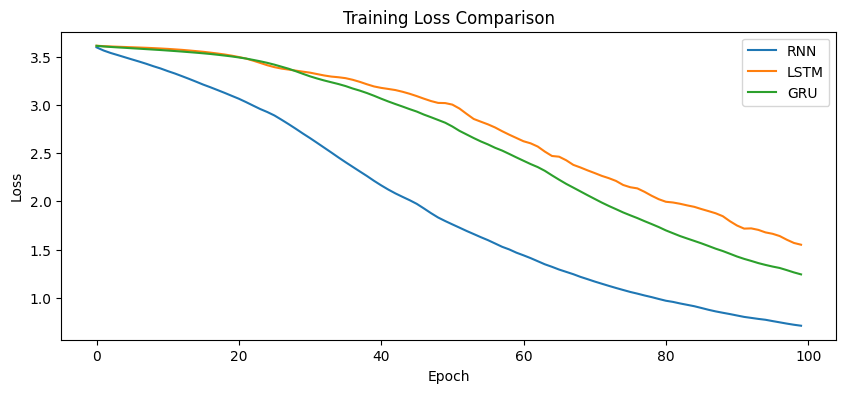

In [8]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [9]:
# Save the first training loss comparison plot
plt.savefig(os.path.join(plots_dir, 'training_loss_comparison_original.png'))
print(f"Saved plot to {os.path.join(plots_dir, 'training_loss_comparison_original.png')}")

Saved plot to plots/training_loss_comparison_original.png


<Figure size 640x480 with 0 Axes>

## 📈 Compare Training Accuracy

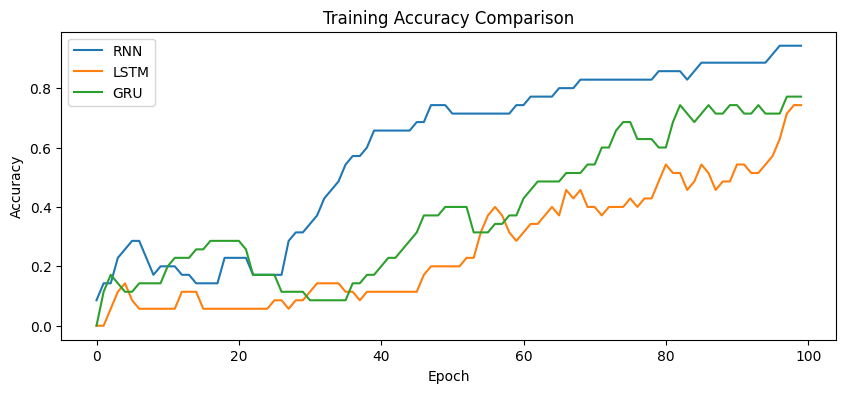

In [10]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['accuracy'], label='RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

In [11]:

plt.savefig(os.path.join(plots_dir, 'training_accuracy_comparison_original.png'))
print(f"Saved plot to {os.path.join(plots_dir, 'training_accuracy_comparison_original.png')}")

Saved plot to plots/training_accuracy_comparison_original.png


<Figure size 640x480 with 0 Axes>

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [12]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [13]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning models models generate meaningful sentences
GRU : deep learning is transforming artificial simpler than


In [14]:
import pandas as pd

metrics = pd.DataFrame({
    "Model": ["Vanilla RNN", "LSTM", "GRU"],
    "Final Loss": [
        rnn_history.history["loss"][-1],
        lstm_history.history["loss"][-1],
        gru_history.history["loss"][-1]
    ],
    "Final Accuracy": [
        rnn_history.history["accuracy"][-1],
        lstm_history.history["accuracy"][-1],
        gru_history.history["accuracy"][-1]
    ]
})

print(metrics)

         Model  Final Loss  Final Accuracy
0  Vanilla RNN    0.710346        0.942857
1         LSTM    1.549858        0.742857
2          GRU    1.242406        0.771429


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

In [15]:
# Task 1: Custom paragraph corpus
custom_corpus = '''
the sun rises slowly over the quiet mountain village
birds begin to sing as the morning light spreads across the valley
farmers walk to their fields carrying tools and baskets
children run along the narrow paths laughing and playing games
the river flows gently past the old stone bridge
travelers stop to rest under the shade of tall trees
in the evening the village gathers near the fire to share stories
the stars appear one by one across the darkening sky
'''
print(custom_corpus)


the sun rises slowly over the quiet mountain village
birds begin to sing as the morning light spreads across the valley
farmers walk to their fields carrying tools and baskets
children run along the narrow paths laughing and playing games
the river flows gently past the old stone bridge
travelers stop to rest under the shade of tall trees
in the evening the village gathers near the fire to share stories
the stars appear one by one across the darkening sky



In [16]:
tokenizer2 = Tokenizer()
tokenizer2.fit_on_texts([custom_corpus])
total_words2 = len(tokenizer2.word_index) + 1
print("Custom corpus vocabulary size:", total_words2)

input_sequences2 = []
for line in custom_corpus.split('\n'):
    token_list = tokenizer2.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences2.append(n_gram_seq)

max_len2 = max(len(seq) for seq in input_sequences2)
input_sequences2 = pad_sequences(input_sequences2, maxlen=max_len2, padding='pre')

X2 = input_sequences2[:, :-1]
y2 = input_sequences2[:, -1]

print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)

Custom corpus vocabulary size: 63
X2 shape: (73, 11)
y2 shape: (73,)


In [17]:
# Tasks 2, 3, 4: larger embedding dim, larger hidden units, more epochs
EMBED_DIM_2 = 100      # Task 2: 32 -> 100
HIDDEN_UNITS_2 = 128   # Task 4: 64 -> 128
EPOCHS_2 = 200         # Task 3: 100 -> 200

def build_and_train2(layer_cls, name):
    tf.random.set_seed(42)
    model = Sequential([
        Embedding(total_words2, EMBED_DIM_2),
        layer_cls(HIDDEN_UNITS_2),
        Dense(total_words2, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    history = model.fit(X2, y2, epochs=EPOCHS_2, verbose=0)
    print(f"{name} training completed | final loss={history.history['loss'][-1]:.4f} "
          f"| final accuracy={history.history['accuracy'][-1]:.4f}")
    return model, history

rnn_model2, rnn_history2 = build_and_train2(SimpleRNN, "Upgraded Vanilla RNN")
lstm_model2, lstm_history2 = build_and_train2(LSTM, "Upgraded LSTM")
gru_model2, gru_history2 = build_and_train2(GRU, "Upgraded GRU")

Upgraded Vanilla RNN training completed | final loss=0.0546 | final accuracy=0.9589
Upgraded LSTM training completed | final loss=0.0982 | final accuracy=0.9726
Upgraded GRU training completed | final loss=0.0575 | final accuracy=0.9589


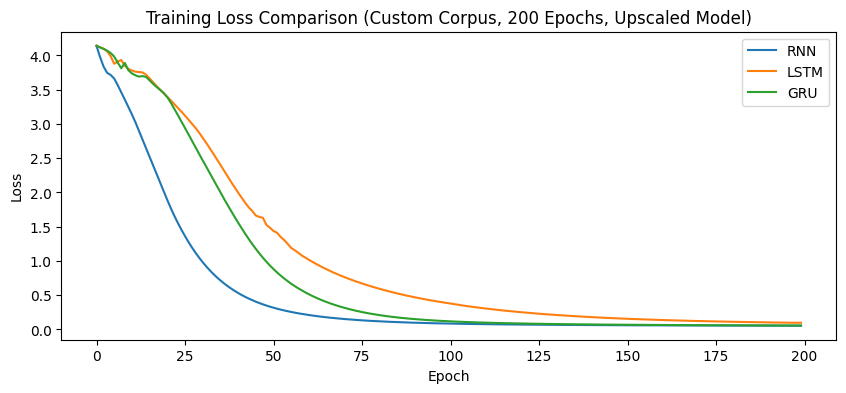

In [18]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history2.history['loss'], label='RNN')
plt.plot(lstm_history2.history['loss'], label='LSTM')
plt.plot(gru_history2.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (Custom Corpus, 200 Epochs, Upscaled Model)")
plt.legend()
plt.show()

## 📈 Compare Training Accuracy (Custom Corpus, Upgraded Models)

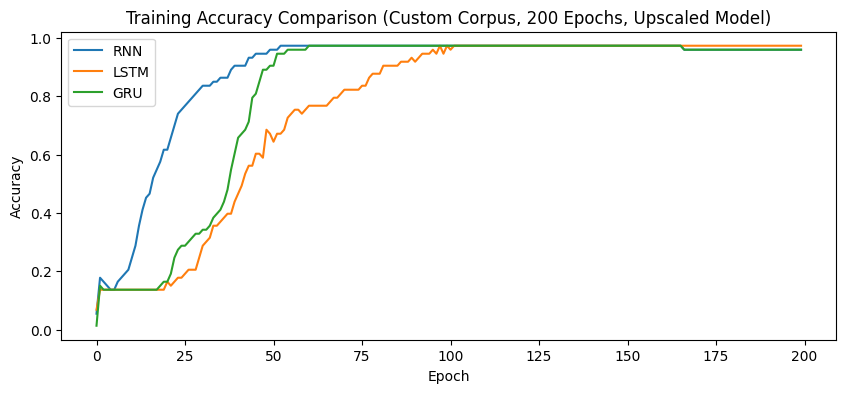

In [19]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history2.history['accuracy'], label='RNN')
plt.plot(lstm_history2.history['accuracy'], label='LSTM')
plt.plot(gru_history2.history['accuracy'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison (Custom Corpus, 200 Epochs, Upscaled Model)")
plt.legend()
plt.show()

In [20]:

plt.savefig(os.path.join(plots_dir, 'training_accuracy_comparison_upgraded.png'))
print(f"Saved plot to {os.path.join(plots_dir, 'training_accuracy_comparison_upgraded.png')}")

Saved plot to plots/training_accuracy_comparison_upgraded.png


<Figure size 640x480 with 0 Axes>

In [21]:

plt.savefig(os.path.join(plots_dir, 'training_loss_comparison_upgraded.png'))
print(f"Saved plot to {os.path.join(plots_dir, 'training_loss_comparison_upgraded.png')}")

Saved plot to plots/training_loss_comparison_upgraded.png


<Figure size 640x480 with 0 Axes>

In [22]:
def generate_text_v2(model, tok, max_len, seed_text, next_words=10): #Task 5 : Generated 10 words
    for _ in range(next_words):
        token_list = tok.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tok.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

seed = "the sun"
print("RNN :", generate_text_v2(rnn_model2, tokenizer2, max_len2, seed, next_words=10))
print("LSTM:", generate_text_v2(lstm_model2, tokenizer2, max_len2, seed, next_words=10))
print("GRU :", generate_text_v2(gru_model2, tokenizer2, max_len2, seed, next_words=10))

RNN : the sun rises slowly over the quiet mountain village gathers near the
LSTM: the sun rises slowly over the quiet mountain village village games games
GRU : the sun rises slowly over the quiet mountain village gathers near the


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

In [23]:
# Save all trained models
rnn_model.save(os.path.join(models_dir, 'rnn_model.keras'))
lstm_model.save(os.path.join(models_dir, 'lstm_model.keras'))
gru_model.save(os.path.join(models_dir, 'gru_model.keras'))

rnn_model2.save(os.path.join(models_dir, 'rnn_model2_upgraded.keras'))
lstm_model2.save(os.path.join(models_dir, 'lstm_model2_upgraded.keras'))
gru_model2.save(os.path.join(models_dir, 'gru_model2_upgraded.keras'))

print(f"All models saved to the '{models_dir}' directory.")

All models saved to the 'models' directory.
